# ROMS Idealized Run — Wind-Driven Upwelling (real model output)

**Runnable companion to [`roms-model-guide.md`](../roms-model-guide.md) §15a
(Idealized test case).**

`UPWELLING` is ROMS's canonical idealized case: a periodic channel where a
steady alongshore wind drives **coastal upwelling** on one side and downwelling
on the other — no external data, fully analytical. This notebook visualises
**real output** from an actual ROMS 4.3 run (built with gfortran).

```bash
# build for UPWELLING (FORT=gfortran), then run — note: ROMS reads stdin
./build_roms.sh -j 4
LC_ALL=C ./romsS < roms_upwelling.in        # → roms_his.nc
```

> **Three things that matter on a fresh box (all hit during this run):**
> 1. ROMS reads its input from **stdin** (`< roms_upwelling.in`), *not* as an
>    argument — passing it as an arg segfaults in `read_PhyPar`.
> 2. Set **`LC_ALL=C`** — a comma-decimal locale (e.g. `id_ID`) makes Fortran's
>    list-directed read reject `300.0`.
> 3. Build with a stable optimizer (`-O2`); aggressive flags miscompiled the
>    solver here.

Committed: a compact extract (SST, a cross-channel temperature section, 21
frames) of the real `roms_his.nc`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

ds = xr.open_dataset(sampledata.roms_upwelling_path())
y = ds["y_km"].values                 # cross-channel distance (km)
Cs = ds["Cs_r"].values                # S-coordinate stretching (-1 bed … 0 surface)
days = ds["time_days"].values
plt.rcParams["figure.dpi"] = 110
print(ds.attrs["title"], "|", ds.attrs["grid"])
print(f"{len(days)} frames over {days[-1]:.1f} days")

Compact real ROMS UPWELLING output | {'tracer': 2, 's_rho': 16, 's_w': 17, 'eta_rho': 82, 'xi_rho': 43, 'eta_psi': 81, 'xi_psi': 42, 'ocean_time': 21, 'eta_u': 82, 'xi_u': 42, 'eta_v': 81, 'xi_v': 43}
21 frames over 5.0 days


## 1 · Surface temperature: the upwelling signature

Cold water reaches the surface at the upwelling coast; the opposite side warms.
The SST contrast across the channel is the headline result of the case.

SST across channel: 17.7 – 22.1 °C


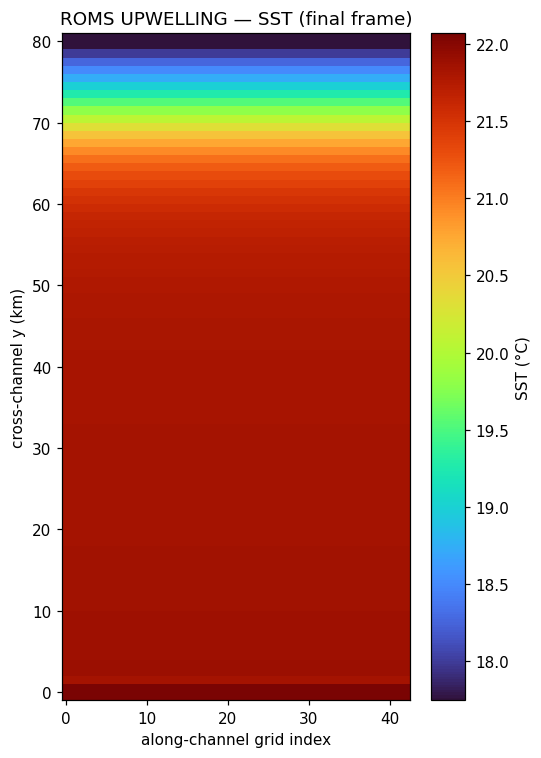

In [2]:
sst = ds["sst"].isel(ocean_time=-1).values        # (eta, xi)
fig, ax = plt.subplots(figsize=(5, 7))
pcm = ax.pcolormesh(np.arange(sst.shape[1]), y, sst, cmap="turbo", shading="auto")
plt.colorbar(pcm, label="SST (°C)")
ax.set(xlabel="along-channel grid index", ylabel="cross-channel y (km)",
       title="ROMS UPWELLING — SST (final frame)")
plt.tight_layout()
print(f"SST across channel: {sst.min():.1f} – {sst.max():.1f} °C")

## 2 · Cross-channel temperature section

The upwelling is clearest in a vertical slice: isotherms **tilt up toward the
coast**, bringing the cold deep water to the surface. The vertical axis is the
S-coordinate stretching (−1 = sea bed, 0 = surface).

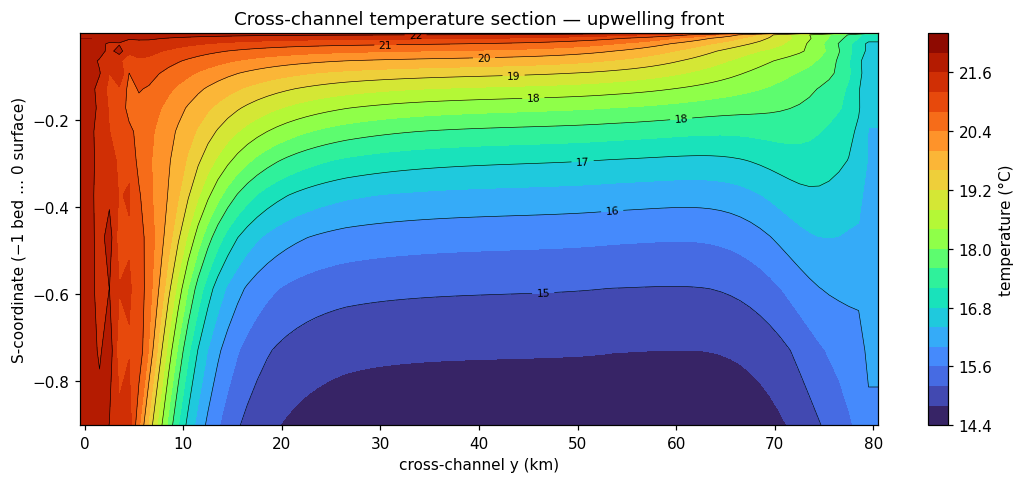

In [3]:
sec = ds["temp_section"].isel(ocean_time=-1).values    # (s_rho, eta)
fig, ax = plt.subplots(figsize=(10, 4.5))
cf = ax.contourf(y, Cs, sec, levels=20, cmap="turbo")
cl = ax.contour(y, Cs, sec, levels=10, colors="k", linewidths=0.4)
ax.clabel(cl, fmt="%.0f", fontsize=7)
plt.colorbar(cf, label="temperature (°C)")
ax.set(xlabel="cross-channel y (km)", ylabel="S-coordinate (−1 bed … 0 surface)",
       title="Cross-channel temperature section — upwelling front")
plt.tight_layout()

## 3 · Evolution of the upwelling

The surface temperature minimum drops as the wind keeps driving cold water up over the 5-day run.

SST contrast grows to 4.3 °C by day 5


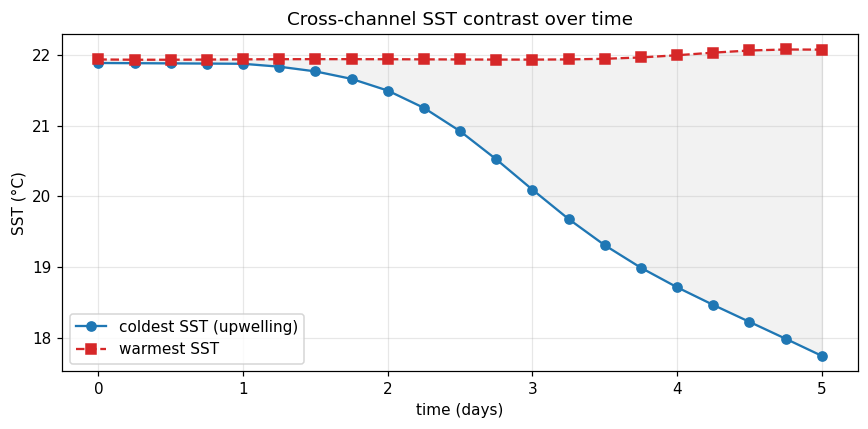

In [4]:
sst_min = ds["sst"].min(dim=["eta_rho", "xi_rho"]).values
sst_max = ds["sst"].max(dim=["eta_rho", "xi_rho"]).values
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(days, sst_min, "o-", color="C0", label="coldest SST (upwelling)")
ax.plot(days, sst_max, "s--", color="C3", label="warmest SST")
ax.fill_between(days, sst_min, sst_max, color="gray", alpha=0.1)
ax.set(xlabel="time (days)", ylabel="SST (°C)", title="Cross-channel SST contrast over time")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
print(f"SST contrast grows to {sst_max[-1]-sst_min[-1]:.1f} °C by day {days[-1]:.0f}")

---
### Reproduce / extend
- Build with `FORT=gfortran`, `MY_HEADER_DIR=ROMS/Include`, then
  `LC_ALL=C ./romsS < roms_upwelling.in`.
- For a real-data regional run (Sunda Strait / Indonesian Throughflow), see the
  ROMS guide §13 and §15b; the SST/section code here transfers directly to a
  `*_his.nc` with `lon_rho/lat_rho`.
- Verify modelled SST against buoys with
  [`../../observations/notebooks/ocean_obs_access.ipynb`](../../observations/notebooks/ocean_obs_access.ipynb).